# Notebook 03: Data Mining — Decision Tree From Scratch

> **KDD Step 4**: Data Mining
>
> Triển khai Decision Tree from scratch (Hunt's Algorithm) trên dữ liệu đã transform.
> Chạy trên cả Scenario A (benchmark) và B (realistic).

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.tree import DecisionTreeClassifier as ScratchDT
from src.metrics import accuracy, precision, recall, f1_score as scratch_f1
from src.metrics import confusion_matrix as scratch_cm, classification_report
from src.visualizer import print_tree_text

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/thacbao/Documents/project/kpdl


## 1. Load Processed Data

In [2]:
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

print(f"Raw dataset: {data['n_raw']:,} rows")
print(f"Cleaned dataset: {data['n_clean']:,} rows")
print(f"Scenario A features: {len(data['scenario_A']['feature_names'])}")
print(f"Scenario B features: {len(data['scenario_B']['feature_names'])}")

Raw dataset: 41,188 rows
Cleaned dataset: 41,176 rows
Scenario A features: 63
Scenario B features: 62


## 2. Giải thích thuật toán Decision Tree

### 2.1 Hunt's Algorithm (đệ quy, top-down, greedy)

**Procedure BuildTree(D_t, node t):**
1. Nếu D_t chứa các bản ghi thuộc cùng một lớp y_t → t là **leaf**, gán nhãn y_t
2. Nếu D_t rỗng → t là **leaf**, gán nhãn mặc định (majority class)
3. Nếu D_t chứa nhiều lớp → tìm **best split**, tạo children, đệ quy

*Ref: DMDWv1.2.md §4.3 "Nhóm thuật toán Hunt"*

### 2.2 Gini Index

$$GINI(t) = 1 - \sum_{i} [p(i|t)]^2$$

- GINI = 0 → pure node (tất cả cùng lớp)
- GINI = 0.5 → impure nhất (binary, phân bố 50/50)

*Ref: DMDWv1.2.md §4.3 "Chỉ số GINI"*

### 2.3 Stopping Criteria

1. Tất cả mẫu cùng lớp → leaf
2. Đạt max_depth → leaf (pre-pruning)
3. Số mẫu < min_samples_split → leaf
4. Gain < min_impurity_decrease → leaf

## 3. Train — Scenario A (Benchmark, có duration)

In [3]:
d_A = data["scenario_A"]

print("=" * 60)
print("  SCENARIO A: BENCHMARK (CÓ DURATION)")
print("=" * 60)
print(f"Train: {d_A['X_train'].shape[0]:,} samples × {d_A['X_train'].shape[1]} features")
print(f"Test:  {d_A['X_test'].shape[0]:,} samples")

dt_A = ScratchDT(criterion="gini", max_depth=5)
dt_A.fit(d_A["X_train"], d_A["y_train"], feature_names=d_A["feature_names"])

y_pred_A = dt_A.predict(d_A["X_test"])

print(f"\nTree depth: {dt_A.get_depth()}")
print(f"Tree leaves: {dt_A.get_n_leaves()}")
print(f"\n--- Classification Report (Scenario A) ---")
report_A, text_A = classification_report(d_A["y_test"], y_pred_A)
print(text_A)

  SCENARIO A: BENCHMARK (CÓ DURATION)
Train: 32,940 samples × 63 features
Test:  8,236 samples



Tree depth: 5
Tree leaves: 31

--- Classification Report (Scenario A) ---
                 precision     recall   f1-score    support
-------------------------------------------------------
             no     0.9397     0.9655     0.9524       7308
            yes     0.6534     0.5119     0.5740        928
-------------------------------------------------------
       accuracy                           0.9144       8236



### 3.1 Visualize Tree — Scenario A

In [4]:
print("Decision Tree Structure (Scenario A — max_depth=5):")
print("=" * 70)
dt_A.print_tree()

Decision Tree Structure (Scenario A — max_depth=5):
nr.employed <= 5087.6500 (samples=32940, gain=0.0297)
├── True:
│   duration <= 162.5000 (samples=3987, gain=0.0912)
│   ├── True:
│   │   pdays <= 6.5000 (samples=1427, gain=0.0156)
│   │   ├── True:
│   │   │   campaign <= 3.5000 (samples=189, gain=0.0268)
│   │   │   ├── True:
│   │   │   │   day_of_week_mon <= 0.5000 (samples=173, gain=0.0261)
│   │   │   │   ├── True:
│   │   │   │   │   → [no] (samples=131, dist={'no': 68, 'yes': 63})
│   │   │   │   └── False:
│   │   │   │       → [no] (samples=42, dist={'no': 33, 'yes': 9})
│   │   │   └── False:
│   │   │       → [no] (samples=16, dist={'no': 16})
│   │   └── False:
│   │       duration <= 123.5000 (samples=1238, gain=0.0112)
│   │       ├── True:
│   │       │   duration <= 77.5000 (samples=807, gain=0.0039)
│   │       │   ├── True:
│   │       │   │   → [no] (samples=311, dist={'no': 308, 'yes': 3})
│   │       │   └── False:
│   │       │       → [no] (samples=496, dist=

### 3.2 Feature Importance — Scenario A

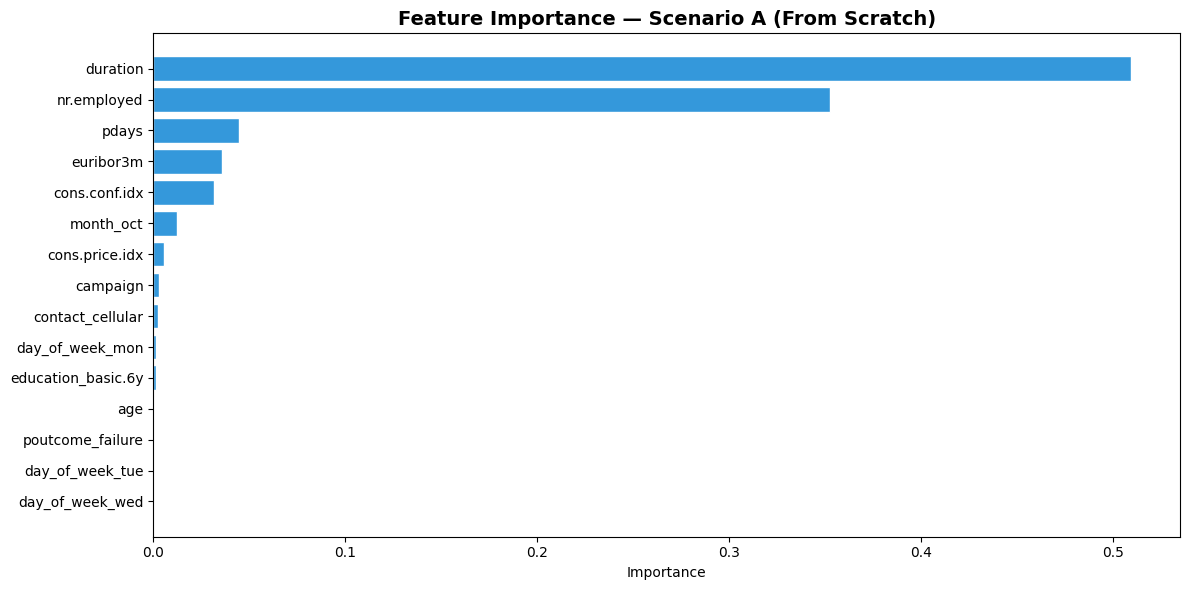

Top 5 features (Scenario A):
  duration: 0.5094
  nr.employed: 0.3525
  pdays: 0.0445
  euribor3m: 0.0357
  cons.conf.idx: 0.0318


In [5]:
# Feature importance
importance_A = dt_A.feature_importances_
feat_names_A = d_A["feature_names"]

# Top 15
idx = np.argsort(importance_A)[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(idx)), importance_A[idx][::-1], color="#3498db", edgecolor="white")
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([feat_names_A[i] for i in idx][::-1])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Scenario A (From Scratch)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/03_feature_importance_A.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features (Scenario A):")
for i in idx[:5]:
    print(f"  {feat_names_A[i]}: {importance_A[i]:.4f}")

## 4. Train — Scenario B (Realistic, không duration)

In [6]:
d_B = data["scenario_B"]

print("=" * 60)
print("  SCENARIO B: REALISTIC (KHÔNG DURATION)")
print("=" * 60)
print(f"Train: {d_B['X_train'].shape[0]:,} samples × {d_B['X_train'].shape[1]} features")
print(f"Test:  {d_B['X_test'].shape[0]:,} samples")

dt_B = ScratchDT(criterion="gini", max_depth=5)
dt_B.fit(d_B["X_train"], d_B["y_train"], feature_names=d_B["feature_names"])

y_pred_B = dt_B.predict(d_B["X_test"])

print(f"\nTree depth: {dt_B.get_depth()}")
print(f"Tree leaves: {dt_B.get_n_leaves()}")
print(f"\n--- Classification Report (Scenario B) ---")
report_B, text_B = classification_report(d_B["y_test"], y_pred_B)
print(text_B)

  SCENARIO B: REALISTIC (KHÔNG DURATION)
Train: 32,940 samples × 62 features
Test:  8,236 samples



Tree depth: 5
Tree leaves: 32

--- Classification Report (Scenario B) ---
                 precision     recall   f1-score    support
-------------------------------------------------------
             no     0.9126     0.9825     0.9462       7308
            yes     0.6522     0.2586     0.3704        928
-------------------------------------------------------
       accuracy                           0.9009       8236



### 4.1 Feature Importance — Scenario B

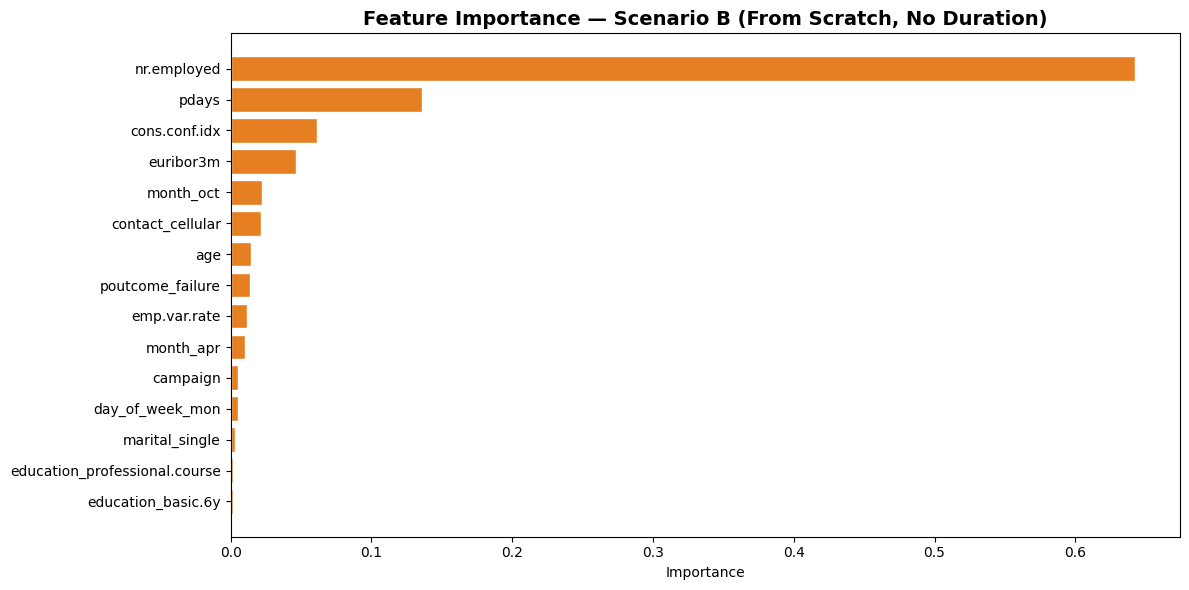

Top 5 features (Scenario B — realistic):
  nr.employed: 0.6422
  pdays: 0.1359
  cons.conf.idx: 0.0611
  euribor3m: 0.0468
  month_oct: 0.0222

→ Không có duration, các features thực tế (poutcome, month, contact...) nổi lên


In [7]:
importance_B = dt_B.feature_importances_
feat_names_B = d_B["feature_names"]
idx_B = np.argsort(importance_B)[::-1][:15]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(idx_B)), importance_B[idx_B][::-1], color="#e67e22", edgecolor="white")
ax.set_yticks(range(len(idx_B)))
ax.set_yticklabels([feat_names_B[i] for i in idx_B][::-1])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Scenario B (From Scratch, No Duration)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/03_feature_importance_B.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features (Scenario B — realistic):")
for i in idx_B[:5]:
    print(f"  {feat_names_B[i]}: {importance_B[i]:.4f}")
print("\n→ Không có duration, các features thực tế (poutcome, month, contact...) nổi lên")

## 5. So sánh Scenario A vs B

In [8]:
print("=" * 65)
print("  SO SÁNH SCENARIO A vs B (FROM SCRATCH)")
print("=" * 65)
print(f"{'Metric':<20s} {'A (Benchmark)':<18s} {'B (Realistic)':<18s}")
print("─" * 65)
for metric_name in ["accuracy", "no", "yes"]:
    if metric_name == "accuracy":
        print(f"{' Accuracy':<20s} {report_A['accuracy']:<18.4f} {report_B['accuracy']:<18.4f}")
    else:
        rA = report_A.get(metric_name, {})
        rB = report_B.get(metric_name, {})
        if rA and rB:
            print(f"  {metric_name} Precision{'':<5s} {rA['precision']:<18.4f} {rB['precision']:<18.4f}")
            print(f"  {metric_name} Recall{'':<8s} {rA['recall']:<18.4f} {rB['recall']:<18.4f}")
            print(f"  {metric_name} F1{'':<12s} {rA['f1-score']:<18.4f} {rB['f1-score']:<18.4f}")

  SO SÁNH SCENARIO A vs B (FROM SCRATCH)
Metric               A (Benchmark)      B (Realistic)     
─────────────────────────────────────────────────────────────────
 Accuracy            0.9144             0.9009            
  no Precision      0.9397             0.9126            
  no Recall         0.9655             0.9825            
  no F1             0.9524             0.9462            
  yes Precision      0.6534             0.6522            
  yes Recall         0.5119             0.2586            
  yes F1             0.5740             0.3704            


## 6. Lưu kết quả

In [9]:
results_scratch = {
    "scenario_A": {
        "y_pred": y_pred_A,
        "report": report_A,
        "feature_importance": importance_A,
        "feature_names": feat_names_A,
        "tree_depth": dt_A.get_depth(),
        "tree_leaves": dt_A.get_n_leaves(),
    },
    "scenario_B": {
        "y_pred": y_pred_B,
        "report": report_B,
        "feature_importance": importance_B,
        "feature_names": feat_names_B,
        "tree_depth": dt_B.get_depth(),
        "tree_leaves": dt_B.get_n_leaves(),
    }
}

with open("data/results_scratch.pkl", "wb") as f:
    pickle.dump(results_scratch, f)

print("Saved: data/results_scratch.pkl")

Saved: data/results_scratch.pkl
